# Pre-call term deposit targeting
A reproducible interview case study: public UCI data, cleaning, EDA, conservative leakage boundary, chronological evaluation, ranked outreach and limitations. The entire source is in `analysis.py`; run this notebook from the project directory.

## 1. Business question and data
With a 20% call capacity, can a model prioritize likely term-deposit subscribers? Source: [Moro et al., UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing). Historical Portugal campaigns, 2008–2010. Subscription is not causal uplift.

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from IPython.display import display, Image
from analysis import ROOT, DATA, FEATURES, NUM, CAT, make_pipe, metric, top_k, main
df = pd.read_csv(DATA, sep=";")
assert len(df) == 41188
display(df.head(), df.shape)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


(41188, 21)

## 2. Data quality and cleaning
`unknown` is a literal category, and -1 in `pdays` is a missing-history sentinel. There are repeated rows but no customer ID to identify repeated clients. Keep rows intact; learn preprocessing on training only.

In [2]:
audit = pd.DataFrame({"dtype":df.dtypes.astype(str), "nulls":df.isna().sum(), "unknown_strings":[int(df[c].eq("unknown").sum()) if df[c].dtype=="object" else 0 for c in df.columns]})
print("Exact duplicate rows:", df.duplicated().sum())
display(audit)

Exact duplicate rows: 12


,dtype,nulls,unknown_strings
age,int64,0,0
job,object,0,330
marital,object,0,80
education,object,0,1731
default,object,0,8597
housing,object,0,990
loan,object,0,990
contact,object,0,0
month,object,0,0
day_of_week,object,0,0


## 3. Exploratory analysis
Observe target imbalance and prior campaign associations; these are descriptive, not causal. The CSV order is temporal, but it lacks a precise timestamp per row.

In [3]:
display(df.y.value_counts().to_frame("rows")); display(df.assign(subscribed=df.y.eq("yes")).groupby("poutcome").subscribed.agg(["mean","count"]).sort_values("mean",ascending=False))
display(df.assign(subscribed=df.y.eq("yes")).groupby("month").subscribed.agg(["mean","count"]).sort_values("mean",ascending=False))

,rows
y,
no,36548
yes,4640


,mean,count
poutcome,,
success,0.651129,1373
failure,0.142286,4252
nonexistent,0.088322,35563


,mean,count
month,,
mar,0.505495,546
dec,0.489011,182
sep,0.449123,570
oct,0.438719,718
apr,0.204787,2632
aug,0.106021,6178
jun,0.105115,5318
nov,0.101439,4101
jul,0.090466,7174


## 4. Leakage-safe modeling
We exclude `duration`: UCI explicitly warns it is known only after a call. We also conservatively drop current-contact and contemporaneous socioeconomic fields. Order split 70/15/15; the validation PR-AUC selects a model; score the test once. The source script contains the full, independently runnable fitting and plotting pipeline.

In [4]:
print("Pre-call columns:", FEATURES)
print("Excluded:", sorted(set(df.columns)-set(FEATURES)-{"y"}))
main()

Pre-call columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'pdays', 'previous', 'poutcome']
Excluded: ['campaign', 'cons.conf.idx', 'cons.price.idx', 'contact', 'day_of_week', 'duration', 'emp.var.rate', 'euribor3m', 'month', 'nr.employed']


{
  "selected_model": "hist_gradient_boosting",
  "test": {
    "pr_auc": 0.4546634399923272,
    "roc_auc": 0.5843372700623555,
    "brier": 0.3089283376374211,
    "top_20pct": {
      "contacts": 1236,
      "subscribers_found": 578,
      "precision": 0.46763754045307443,
      "overall_rate": 0.38452824081566594,
      "lift": 1.216133149183311,
      "capture_rate": 0.24326599326599327
    }
  },
  "test_at_validation_threshold": {
    "contacts": 3131,
    "precision": 0.44778026189715747,
    "recall": 0.5900673400673401,
    "confusion_matrix": [
      [
        2074,
        1729
      ],
      [
        974,
        1402
      ]
    ]
  }
}


## 5. Evaluation and operating decision
Read the actual generated results. A fixed 20% queue means selecting the highest-scoring fifth **of each batch**, not using an old probability cutoff. Compare PR-AUC to period prevalence and inspect the calibration curve before any use of probability values.

In [5]:
import json
r=json.loads((ROOT/"outputs"/"metrics.json").read_text())
display(pd.DataFrame({"train":r["splits"]["train"],"validation":r["splits"]["validation"],"test":r["splits"]["test"]}))
display(pd.DataFrame(r["validation"]).T)
print("Chosen:",r["selected_model"],"Test:",r["test"]);print("Fixed validation threshold on test:",r["test_at_validation_threshold"])

,train,validation,test
rows,28831.000000,6178.000000,6179.000000
subscribers,1606.000000,658.000000,2376.000000
rate,0.055704,0.106507,0.384528


,pr_auc,roc_auc,brier,top_20pct
logistic,0.18954,0.616881,0.258845,"{'contacts': 1236, 'subscribers_found': 234, '..."
hist_gradient_boosting,0.189923,0.619765,0.095068,"{'contacts': 1236, 'subscribers_found': 242, '..."


Chosen: hist_gradient_boosting Test: {'pr_auc': 0.4546634399923272, 'roc_auc': 0.5843372700623555, 'brier': 0.3089283376374211, 'top_20pct': {'contacts': 1236, 'subscribers_found': 578, 'precision': 0.46763754045307443, 'overall_rate': 0.38452824081566594, 'lift': 1.216133149183311, 'capture_rate': 0.24326599326599327}}
Fixed validation threshold on test: {'contacts': 3131, 'precision': 0.44778026189715747, 'recall': 0.5900673400673401, 'confusion_matrix': [[2074, 1729], [974, 1402]]}


01_overview.png


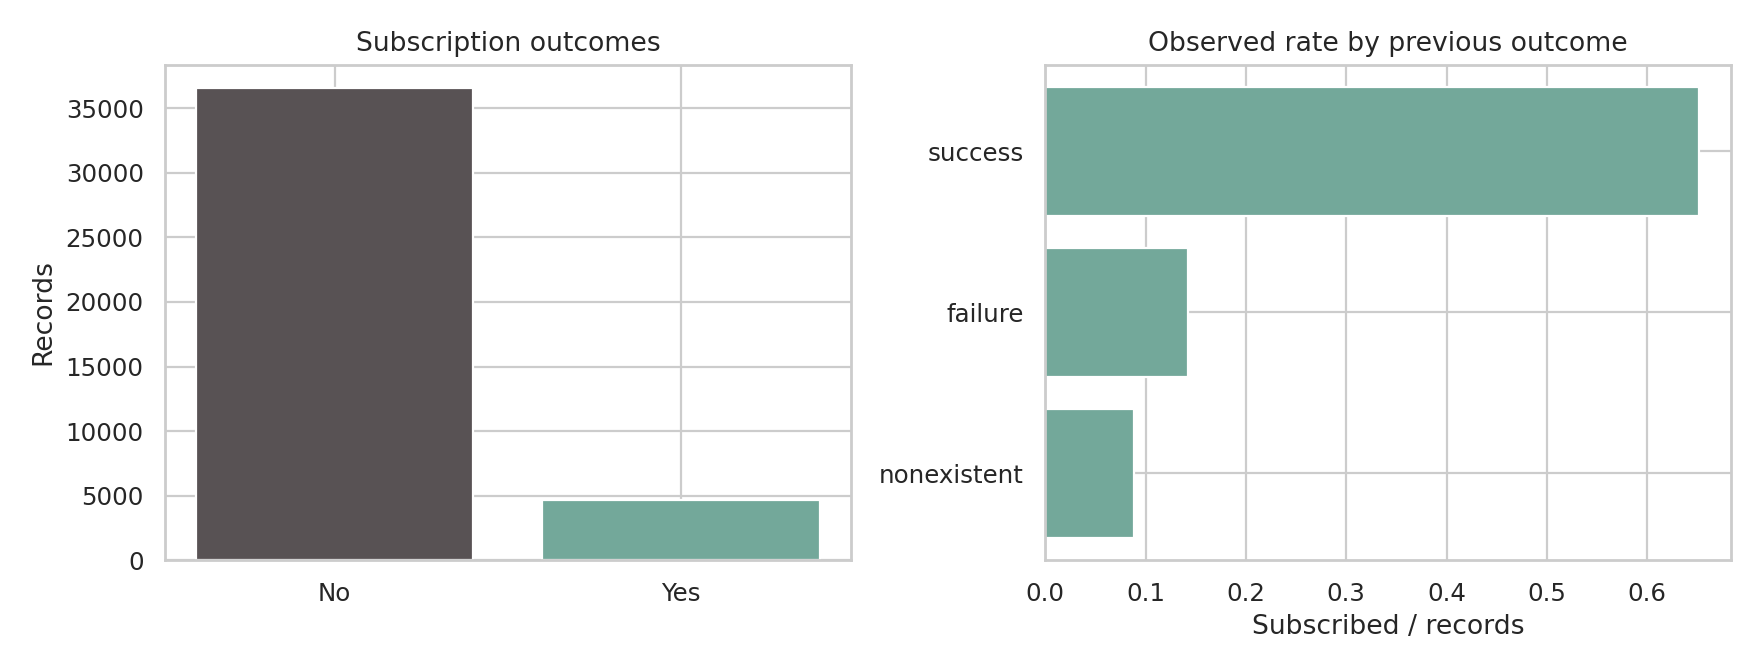

02_model_quality.png


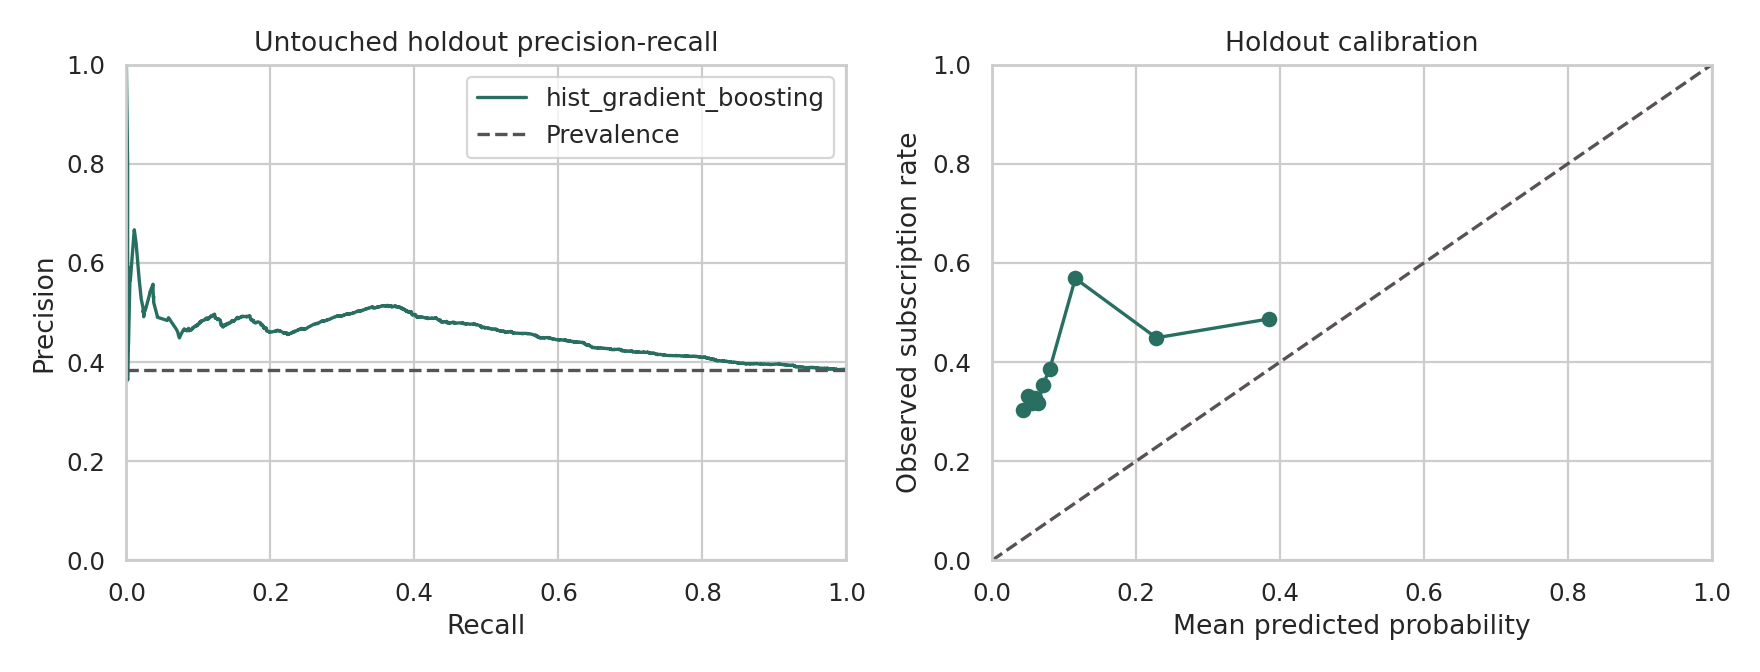

03_operating_point.png


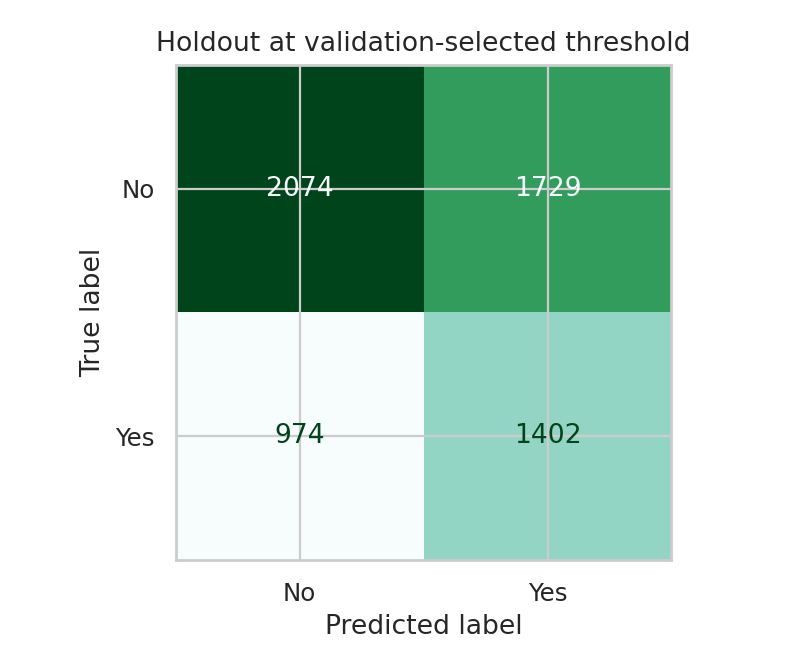

04_decile_lift.png


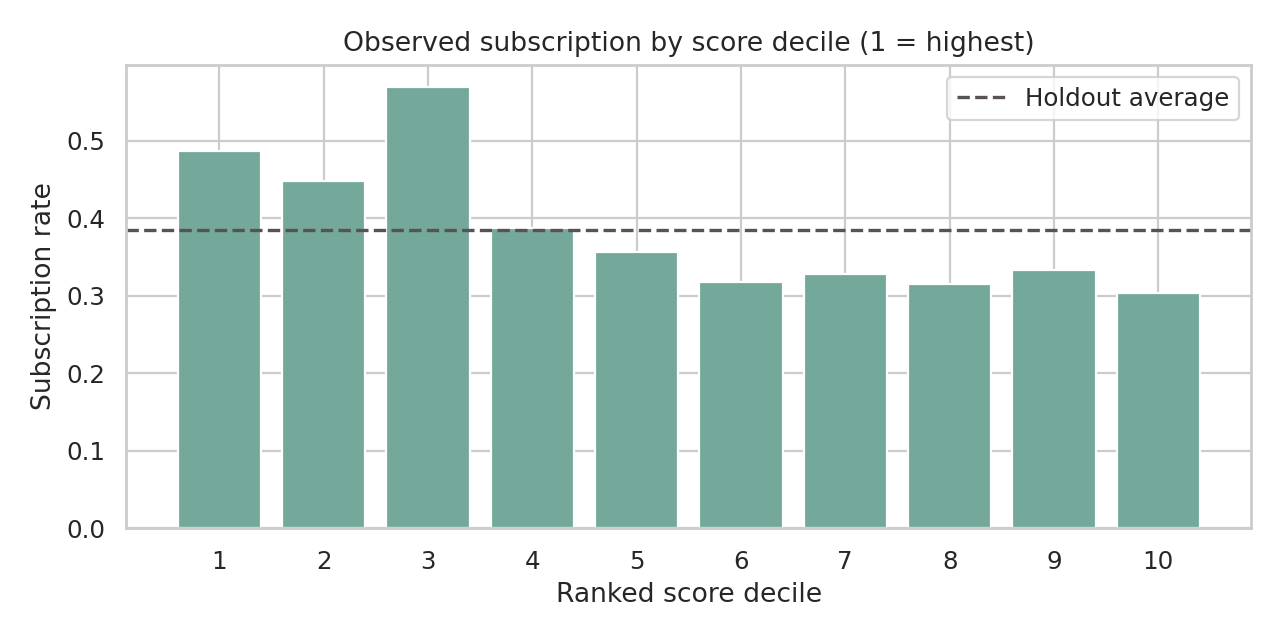

In [6]:
for name in ("01_overview.png", "02_model_quality.png", "03_operating_point.png", "04_decile_lift.png"):
    print(name)
    display(Image(filename=str(ROOT/"outputs"/name),width=850))

## 6. Interpretation and next steps
Holdout prevalence 38.45% versus 5.57% in training, a sharp temporal shift. The 20% queue captures 578/2,376 subscribers, only 1.22x the test base rate. Validation-picked threshold would call roughly half the test slice. A prospective experiment with contact costs, consent rules, time-stamped customer IDs and a randomized holdout is needed before claiming ROI. This is a historical portfolio example, not a production recommendation.